<table border=1 width="100%"><tr><td bgcolor="#B00A0F">
<h1><font color="#FFFFFF">&nbsp; Selección de Umbrales — Variables Objetivo</font></h1>
</td></tr></table>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

In [ ]:
# 1. Cargar el dataset (el delimitador es punto y coma según la estructura de tu web scraping)
df = pd.read_csv('BD/bd_liga1_Peru_entrenamiento.csv', sep=';')

# 2. Definir las estadísticas base
columnas_estadisticas = [
    'goles', 'Posesión de pelota', 'Goles esperados (xG)', 'Tiros totales', 
    'Tiros a puerta', 'Disparos al palo', 'Tiros fuera', 'Tiros bloqueados', 
    'Tiros adentro del area', 'Tiros desde fuera del area', 'Fueras de juego', 
    'Pases', 'Pases precisos', 'Saques de banda', 'Pases al ultimo tercio', 
    'Entradas', 'Intercepciones', 'Recuperaciones', 'Despejes', 'Corners', 'Faltas'
]

# 3. Desdoblar los datos para los equipos LOCALES
df_local = df[['fecha', 'equipo_local', 'equipo_visitante']].copy()
df_local.columns = ['Fecha', 'Equipo', 'Rival']
df_local['Local'] = 1

for col in columnas_estadisticas:
    df_local[col] = df[f'{col}_local']

# 4. Desdoblar los datos para los equipos VISITANTES
df_visitante = df[['fecha', 'equipo_visitante', 'equipo_local']].copy()
df_visitante.columns = ['Fecha', 'Equipo', 'Rival']
df_visitante['Local'] = 0

for col in columnas_estadisticas:
    df_visitante[col] = df[f'{col}_visitante']

# 5. Unir ambos sub-conjuntos en un solo dataset (formato vertical/pivotado)
df_estructurado = pd.concat([df_local, df_visitante], ignore_index=True)

# 6. Convertir la fecha a formato de tiempo real y ordenar cronológicamente por equipo
df_estructurado['Fecha'] = pd.to_datetime(df_estructurado['Fecha'], format='%d/%m/%Y')
df_estructurado = df_estructurado.sort_values(by=['Equipo', 'Fecha']).reset_index(drop=True)

# 7. Crear los 3 Targets independientes (uno por variable objetivo)
df_estructurado['Target_XG']    = np.where(df_estructurado['Goles esperados (xG)'] >= 1.5, 1, 0)
df_estructurado['Target_Tiros'] = np.where(df_estructurado['Tiros a puerta'] >= 5, 1, 0)
df_estructurado['Target_Goles'] = np.where(df_estructurado['goles'] >= 2, 1, 0)

# Verificar el resultado final
print("Dimensiones del nuevo dataset:", df_estructurado.shape)
print("\nDistribución de cada Target:")
for t in ['Target_XG', 'Target_Tiros', 'Target_Goles']:
    n1 = df_estructurado[t].sum()
    n0 = len(df_estructurado) - n1
    print(f"  {t}: Clase 0 = {n0} ({n0/len(df_estructurado)*100:.1f}%)  |  Clase 1 = {n1} ({n1/len(df_estructurado)*100:.1f}%)")

print("\nMuestra de las variables clave calculadas:")
print(df_estructurado[['Fecha', 'Equipo', 'Rival', 'Local', 'Goles esperados (xG)', 'Tiros a puerta', 'goles', 'Target_XG', 'Target_Tiros', 'Target_Goles']].head(5))

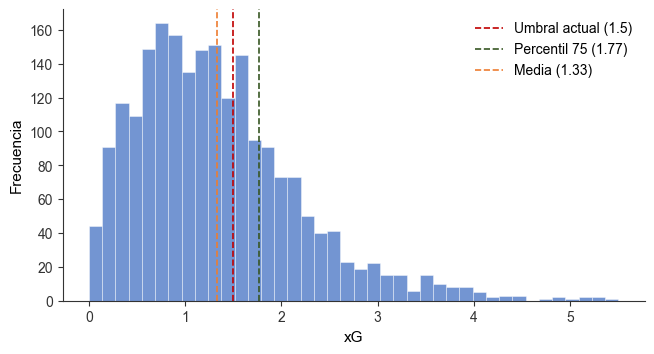

In [4]:
# Configuración global estilo APA
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Calibri', 'DejaVu Sans'],
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

xg = df_estructurado['Goles esperados (xG)']
media = xg.mean()
p75  = xg.quantile(0.75)

fig, ax = plt.subplots(figsize=(6.5, 3.5))  # Ancho aprox. de una página Word

ax.hist(xg, bins=40, color='#4472C4', alpha=0.75, edgecolor='white', linewidth=0.4)

ax.axvline(1.5,   color='#C00000', linestyle='--', linewidth=1.2,
           label=f'Umbral actual (1.5)')
ax.axvline(p75,   color='#375623', linestyle='--', linewidth=1.2,
           label=f'Percentil 75 ({p75:.2f})')
ax.axvline(media, color='#ED7D31', linestyle='--', linewidth=1.2,
           label=f'Media ({media:.2f})')

ax.set_xlabel('xG', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.legend(frameon=False, fontsize=10)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(pad=0.5)
plt.savefig('distribucion_xg.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

In [6]:
umbrales = [1.0, 1.2, 1.3, 1.5, 1.7, 2.0]

print(f"{'Umbral':<10} {'Clase 0':<12} {'Clase 1':<12} {'% Clase 1':<12}")
print("-" * 46)
for u in umbrales:
    y_temp = (df_estructurado['Goles esperados (xG)'] > u).astype(int)
    n0 = (y_temp == 0).sum()
    n1 = (y_temp == 1).sum()
    pct = n1 / len(y_temp) * 100
    marca = " *" if u == 1.5 else ""
    print(f"{u:<10} {n0:<12} {n1:<12} {pct:.1f}%{marca}")

print("\n* Umbral seleccionado")

Umbral     Clase 0      Clase 1      % Clase 1   
----------------------------------------------
1.0        874          1282         59.5%
1.2        1086         1070         49.6%
1.3        1183         973          45.1%
1.5        1374         782          36.3% *
1.7        1574         582          27.0%
2.0        1768         388          18.0%

* Umbral seleccionado


In [ ]:
tiros = df_estructurado['Tiros a puerta']

print("=== Distribución de Tiros a Puerta en Liga 1 ===")
print(tiros.describe())
print(f"\nPercentil 60: {tiros.quantile(0.60):.2f}")
print(f"Percentil 70: {tiros.quantile(0.70):.2f}")
print(f"Percentil 75: {tiros.quantile(0.75):.2f}")
print(f"Media: {tiros.mean():.2f}")

# Tabla comparativa de umbrales para tiros a puerta
umbrales_tiros = [2, 3, 4, 5, 6]
print(f"\n{'Umbral':<10} {'Clase 0':<12} {'Clase 1':<12} {'% Clase 1':<12}")
print("-" * 46)
for u in umbrales_tiros:
    y_temp = (df_estructurado['Tiros a puerta'] >= u).astype(int)
    n0 = (y_temp == 0).sum()
    n1 = (y_temp == 1).sum()
    pct = n1 / len(y_temp) * 100
    marca = " *" if u == 5 else ""
    print(f"{u:<10} {n0:<12} {n1:<12} {pct:.1f}%{marca}")

print("\n* Umbral seleccionado (Tiros a puerta >= 5)")

In [ ]:
tiros = df_estructurado['Tiros a puerta']
media_t = tiros.mean()
p75_t   = tiros.quantile(0.75)
mediana_t = tiros.median()

fig, ax = plt.subplots(figsize=(6.5, 3.5))

ax.hist(tiros, bins=range(0, 18), color='#4472C4', alpha=0.75,
        edgecolor='white', linewidth=0.4)

ax.axvline(5,        color='#C00000', linestyle='--', linewidth=1.2,
           label='Umbral seleccionado (≥ 5)')
ax.axvline(p75_t,    color='#375623', linestyle='--', linewidth=1.2,
           label=f'Percentil 75 ({p75_t:.0f})')
ax.axvline(media_t,  color='#ED7D31', linestyle='--', linewidth=1.2,
           label=f'Media ({media_t:.2f})')
ax.axvline(mediana_t,color='#7030A0', linestyle='--', linewidth=1.2,
           label=f'Mediana ({mediana_t:.0f})')

ax.set_xlabel('Tiros a puerta', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(pad=0.5)
plt.savefig('distribucion_tiros_puerta.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
goles = df_estructurado['goles']

print("=== Distribución de Goles en Liga 1 ===")
print(goles.describe())
print(f"\nPartidos con 0 goles: {(goles == 0).sum()} ({(goles == 0).mean()*100:.1f}%)")
print(f"Partidos con 1 gol:   {(goles == 1).sum()} ({(goles == 1).mean()*100:.1f}%)")
print(f"Partidos con 2 goles: {(goles == 2).sum()} ({(goles == 2).mean()*100:.1f}%)")
print(f"Partidos con 3+ goles:{(goles >= 3).sum()} ({(goles >= 3).mean()*100:.1f}%)")

# Tabla comparativa de umbrales para goles
umbrales_goles = [1, 2, 3, 4]
print(f"\n{'Umbral':<10} {'Clase 0':<12} {'Clase 1':<12} {'% Clase 1':<12}")
print("-" * 46)
for u in umbrales_goles:
    y_temp = (df_estructurado['goles'] >= u).astype(int)
    n0 = (y_temp == 0).sum()
    n1 = (y_temp == 1).sum()
    pct = n1 / len(y_temp) * 100
    marca = " *" if u == 2 else ""
    print(f"{u:<10} {n0:<12} {n1:<12} {pct:.1f}%{marca}")

print("\n* Umbral seleccionado (Goles >= 2)")

# Histograma
fig, ax = plt.subplots(figsize=(6.5, 3.5))

ax.hist(goles, bins=range(0, int(goles.max()) + 2),
        color='#4472C4', alpha=0.75,
        edgecolor='white', linewidth=0.4,
        align='left')

ax.axvline(1.5, color='#C00000', linestyle='--', linewidth=1.2,
           label='Umbral seleccionado (≥ 2 goles)')
ax.axvline(goles.mean(), color='#ED7D31', linestyle='--', linewidth=1.2,
           label=f'Media ({goles.mean():.2f})')

ax.set_xlabel('Goles anotados por equipo', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_xticks(range(0, int(goles.max()) + 1))
ax.legend(frameon=False, fontsize=10)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(pad=0.5)
plt.savefig('distribucion_goles.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
targets = {
    'Target_XG\n(xG ≥ 1.5)':       'Target_XG',
    'Target_Tiros\n(Tiros ≥ 5)':    'Target_Tiros',
    'Target_Goles\n(Goles ≥ 2)':    'Target_Goles',
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)

for ax, (titulo, col) in zip(axes, targets.items()):
    conteo = df_estructurado[col].value_counts().sort_index()
    valores = conteo.values
    total = valores.sum()
    etiquetas = ['Clase 0', 'Clase 1']

    barras = ax.bar(etiquetas, valores,
                    color=['#4472C4', '#C00000'],
                    alpha=0.85, edgecolor='white',
                    linewidth=0.5, width=0.5)

    for barra, val in zip(barras, valores):
        pct = val / total * 100
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 10,
                f'{val:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=10)

    ax.set_title(titulo, fontsize=11, pad=10)
    ax.set_ylabel('Número de observaciones', fontsize=10)
    ax.set_ylim(0, max(valores) * 1.25)
    ax.tick_params(axis='both', labelsize=10)
    ax.yaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

plt.tight_layout(pad=1.0)
plt.savefig('distribucion_targets.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

print("\nResumen de distribución de los 3 Targets:")
for titulo, col in targets.items():
    n1 = df_estructurado[col].sum()
    n0 = len(df_estructurado) - n1
    print(f"  {col}: Clase 0 = {n0:,} ({n0/len(df_estructurado)*100:.1f}%)  |  Clase 1 = {n1:,} ({n1/len(df_estructurado)*100:.1f}%)")